# Task 2: Exploratory Data Analysis – Xente eCommerce Transactions

This notebook explores the transaction-level dataset to understand data quality, distributions, relationships, and potential features for credit risk modeling.  
The goal is to form hypotheses for the feature engineering and proxy target definition stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/raw/data.csv', parse_dates=['TransactionStartTime'])
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


## 1. Data Overview
- Number of rows and columns
- Data types of each column
- Basic memory usage

In [4]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   TransactionId         95662 non-null  str                
 1   BatchId               95662 non-null  str                
 2   AccountId             95662 non-null  str                
 3   SubscriptionId        95662 non-null  str                
 4   CustomerId            95662 non-null  str                
 5   CurrencyCode          95662 non-null  str                
 6   CountryCode           95662 non-null  int64              
 7   ProviderId            95662 non-null  str                
 8   ProductId             95662 non-null  str                
 9   ProductCategory       95662 non-null  str                
 10  ChannelId             95662 non-null  str                
 11  Amount                95662 non-null  float64            
 12  Value          

## 2. Summary Statistics
Central tendency, dispersion, and shape of numerical features.

In [6]:
df.describe(include='all')

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
count,95662,95662,95662,95662,95662,95662,95662.0,95662,95662,95662,95662,9.566200e+04,9.566200e+04,95662,95662.000000,95662.000000
unique,95662,94809,3633,3627,3742,1,NaN,6,23,9,4,NaN,NaN,NaN,NaN,NaN
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,NaN,ProviderId_4,ProductId_6,financial_services,ChannelId_3,NaN,NaN,NaN,NaN,NaN
freq,1,28,30893,32630,4091,95662,NaN,38189,32635,45405,56935,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,6.717846e+03,9.900584e+03,2019-01-02 01:15:52.886433+00:00,2.255974,0.002018
min,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,-1.000000e+06,2.000000e+00,2018-11-15 02:18:49+00:00,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,-5.000000e+01,2.750000e+02,2018-12-12 09:47:57.750000+00:00,2.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,1.000000e+03,1.000000e+03,2018-12-31 17:20:45+00:00,2.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,2.800000e+03,5.000000e+03,2019-01-25 10:54:47.500000+00:00,2.000000,0.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,9.880000e+06,9.880000e+06,2019-02-13 10:01:28+00:00,4.000000,1.000000


## 3. Distribution of Numerical Features
- `Amount`: positive for debits, negative for credits  
- `Value`: absolute value of Amount

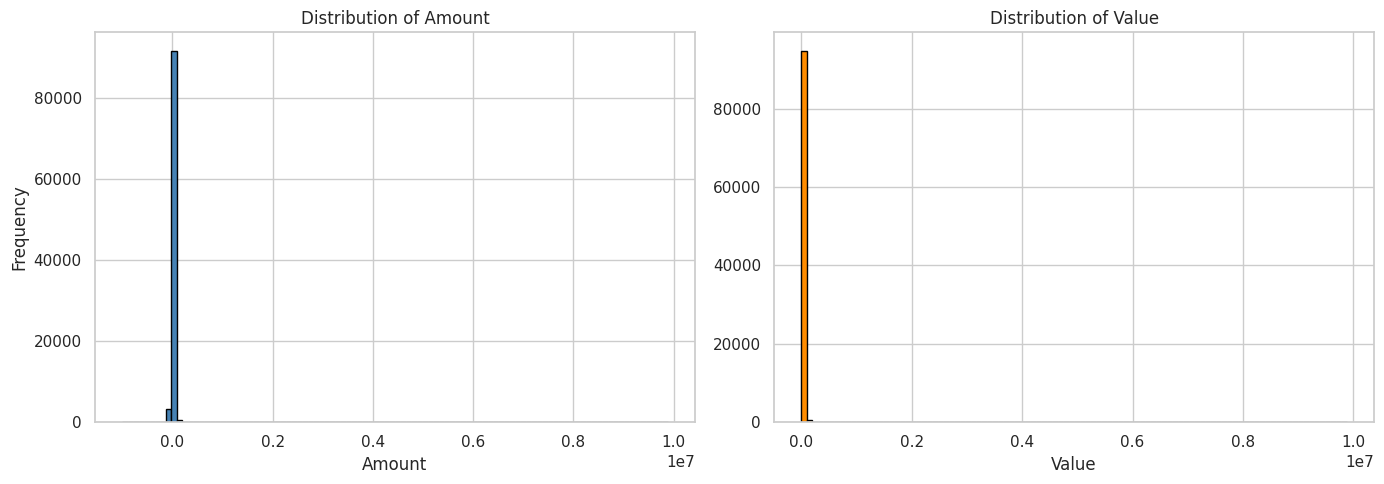

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount
axes[0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Value
axes[1].hist(df['Value'], bins=100, color='darkorange', edgecolor='black')
axes[1].set_title('Distribution of Value')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.show()

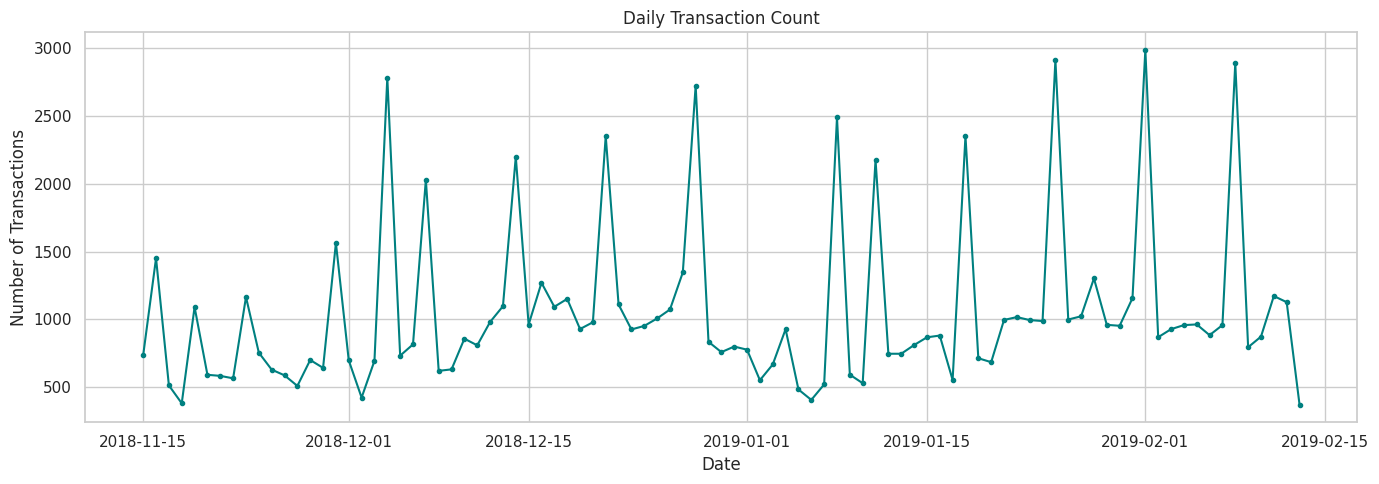

In [8]:
# Transactions over time
df_time = df.set_index('TransactionStartTime').resample('D')['TransactionId'].count()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_time.index, df_time.values, marker='o', markersize=3, linestyle='-', color='teal')
ax.set_title('Daily Transaction Count')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

## 4. Distribution of Categorical Features
Explore the frequency and variety of categorical columns: `ProductCategory`, `ChannelId`, `PricingStrategy`, `FraudResult`, etc.

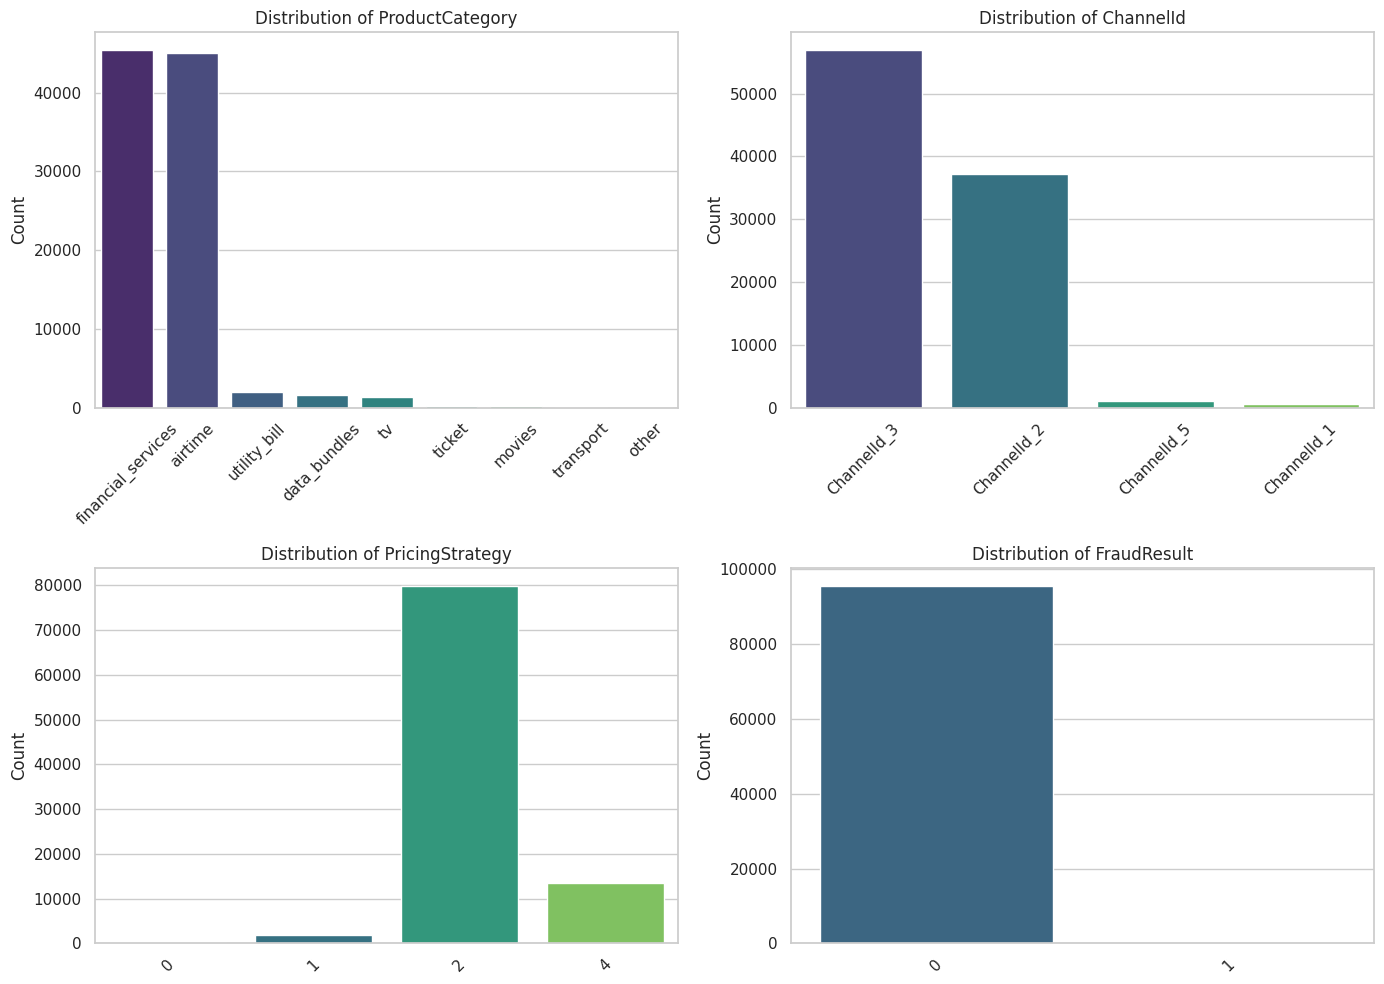

In [9]:
cat_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy', 'FraudResult']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Correlation Analysis
Examine relationships between numerical features.  
Since there are only two numerical columns, we also look at encoded categorical variables.

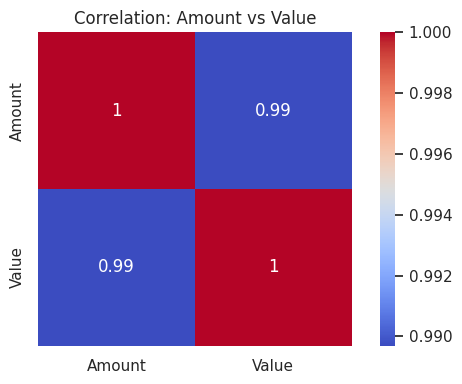

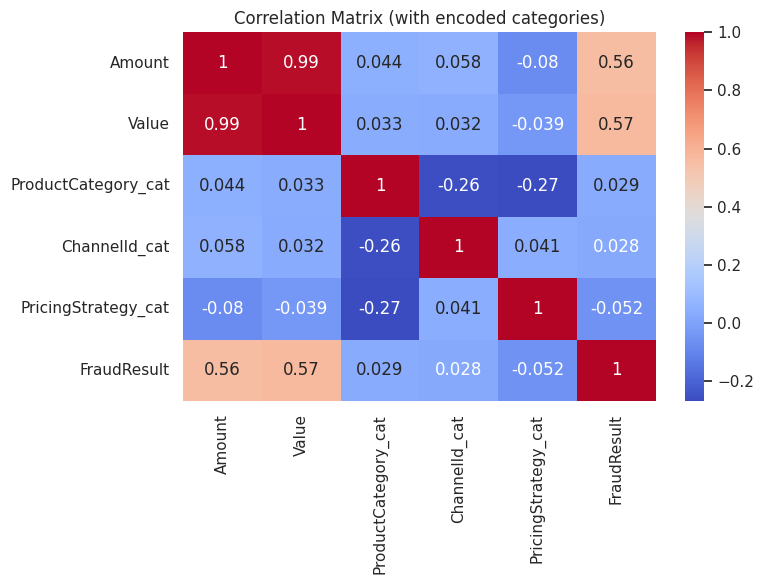

In [10]:
num_cols = ['Amount', 'Value']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True, ax=ax)
ax.set_title('Correlation: Amount vs Value')
plt.tight_layout()
plt.show()

# Add a few encoded categorical columns for a broader view
df_encoded = df.copy()
for col in ['ProductCategory', 'ChannelId', 'PricingStrategy']:
    df_encoded[col + '_cat'] = df_encoded[col].astype('category').cat.codes

corr_full = df_encoded[['Amount', 'Value', 'ProductCategory_cat', 'ChannelId_cat', 'PricingStrategy_cat', 'FraudResult']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix (with encoded categories)')
plt.tight_layout()
plt.show()

## 6. Missing Values
Identify missing data and decide on handling strategies.

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if missing_df.empty:
    print('No missing values in the dataset.')
else:
    print(missing_df)

No missing values in the dataset.


## 7. Outlier Detection
Box plots for numerical features to spot extreme values.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Amount'], ax=axes[0], color='lightblue')
axes[0].set_title('Amount Box Plot')

sns.boxplot(y=df['Value'], ax=axes[1], color='lightgreen')
axes[1].set_title('Value Box Plot')

plt.tight_layout()
plt.show()